# Prediction error growth vs forecast horizon

Ноутбук строит графики роста ошибки модели относительно SGP4/TLE по мере увеличения горизонта прогноза.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
REPO_URL = 'https://github.com/Gavr101/space_modeling.git'
REPO_DIR = Path('/content/space_modeling') if IN_COLAB else Path.cwd()


def run(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)

if IN_COLAB:
    if not REPO_DIR.exists():
        run(['git', 'clone', REPO_URL, str(REPO_DIR)])
    os.chdir(REPO_DIR)

    run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'])
    run([sys.executable, '-m', 'pip', 'install', '-e', '.'])
    print('Dependencies installed. Working dir:', Path.cwd())
    # Optional: NRLMSISE-00 improves drag density modeling when available.
    try:
        run([sys.executable, '-m', 'pip', 'install', 'nrlmsise00'])
    except Exception as exc:
        print('Optional dependency nrlmsise00 was not installed:', exc)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import timezone, timedelta

from sgp4.api import Satrec, jday
from sgp4.conveniences import sat_epoch_datetime

if IN_COLAB:
    from dynamics.propagator import PropagationConfig, propagate_orbit
    from visualization.orbit_3d import build_orbit_figure
    from visualization.map_2d import build_groundtrack_figure
else:
    import sys
    sys.path.append('..')
    from dynamics.propagator import PropagationConfig, SpacecraftProperties, propagate_orbit
    from visualization.orbit_3d import build_orbit_figure
    from visualization.map_2d import build_groundtrack_figure

In [12]:
# Реальные TLE (пример). При необходимости замените на более свежие с CelesTrak.
TLES = {
    'ISS (ZARYA)': (
        '1 25544U 98067A   26128.52749306  .00016178  00000+0  29081-3 0  9998',
        '2 25544  51.6389 262.3902 0003522 120.6870 311.5993 15.50359005504712',
    ),
    'STARLINK-1008': (
        '1 44714U 19074B   26128.32137731  .00003179  00000+0  23789-3 0  9991',
        '2 44714  53.0540 170.1880 0001221  99.9037 260.2108 15.06387939356311',
    ),
}

EARTH_RADIUS_M = 6_378_137.0

In [25]:
def sgp4_state_samples(tle1, tle2, duration_hours=12, step_seconds=60):
    sat = Satrec.twoline2rv(tle1, tle2)
    epoch = sat_epoch_datetime(sat).replace(tzinfo=timezone.utc)

    samples = []
    times = []
    for dt_s in range(0, int(duration_hours * 3600) + 1, step_seconds):
        t = epoch + timedelta(seconds=dt_s)
        jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second + t.microsecond / 1e6)
        e, r_km, v_km_s = sat.sgp4(jd, fr)
        if e != 0:
            raise RuntimeError(f'SGP4 error code: {e}')
        samples.append(np.array([*r_km, *v_km_s], dtype=float))
        times.append(t)

    states = np.array(samples)
    states[:, :3] *= 1000.0
    states[:, 3:] *= 1000.0
    return np.array(times), states


def model_from_initial_state(initial_state, duration_hours=12, step_seconds=60,
                             spacecraft_prop=SpacecraftProperties(5.0, 2.2, 1.3, 0.05)
                             ):
    cfg = PropagationConfig(
        initial_state=initial_state,
        epoch_seconds=0.0,
        duration_seconds=duration_hours * 3600,
        step_seconds=step_seconds,
        spacecraft = spacecraft_prop
    )
    # Для Colab-совместимости: оставляем drag на fallback-плотности,
    # чтобы избежать падений при несовместимых версиях nrlmsise00.
    cfg.environment.force_models.nrlmsise00_atmosphere = False
    times, states = propagate_orbit(cfg)
    return times, states

In [35]:
sat_name = 'STARLINK-1008'
d_spacecraft_prop = {
    'ISS (ZARYA)': SpacecraftProperties(mass=420000.0, cd=2.2, cr=1.3, reference_area=400.0),
    'STARLINK-1008': SpacecraftProperties(mass=295.0, cd=2.2, cr=1.2, reference_area=4.0),
}
tle1, tle2 = TLES[sat_name]

forecast_horizon_h = 12
step_seconds = 60

_, states_ref = sgp4_state_samples(tle1, tle2, duration_hours=forecast_horizon_h, step_seconds=step_seconds)
_, states_model = model_from_initial_state(states_ref[0], duration_hours=forecast_horizon_h, step_seconds=step_seconds,
                                           spacecraft_prop=d_spacecraft_prop[sat_name]
                                           )

r_ref = states_ref[:, :3]
v_ref = states_ref[:, 3:]
r_model = states_model[:, :3]
v_model = states_model[:, 3:]

h_ref = np.linalg.norm(r_ref, axis=1) - EARTH_RADIUS_M
h_model = np.linalg.norm(r_model, axis=1) - EARTH_RADIUS_M

delta_h = np.abs(h_model - h_ref)
delta_r = np.linalg.norm(r_model - r_ref, axis=1)
delta_v = np.linalg.norm(v_model - v_ref, axis=1)

t_hours = np.arange(len(delta_h)) * step_seconds / 3600.0

print(f'Satellite: {sat_name}')
print(f'Max altitude residual: {delta_h.max()/1000:.2f} km')
print(f'Max position residual: {delta_r.max()/1000:.2f} km')
print(f'Max speed residual: {delta_v.max():.2f} m/s')

delta_h_km = delta_h / 1000.0
delta_r_km = delta_r / 1000.0
delta_v_km_s = delta_v / 1000.0

Satellite: STARLINK-1008
Max altitude residual: 0.15 km
Max position residual: 0.31 km
Max speed residual: 0.21 m/s


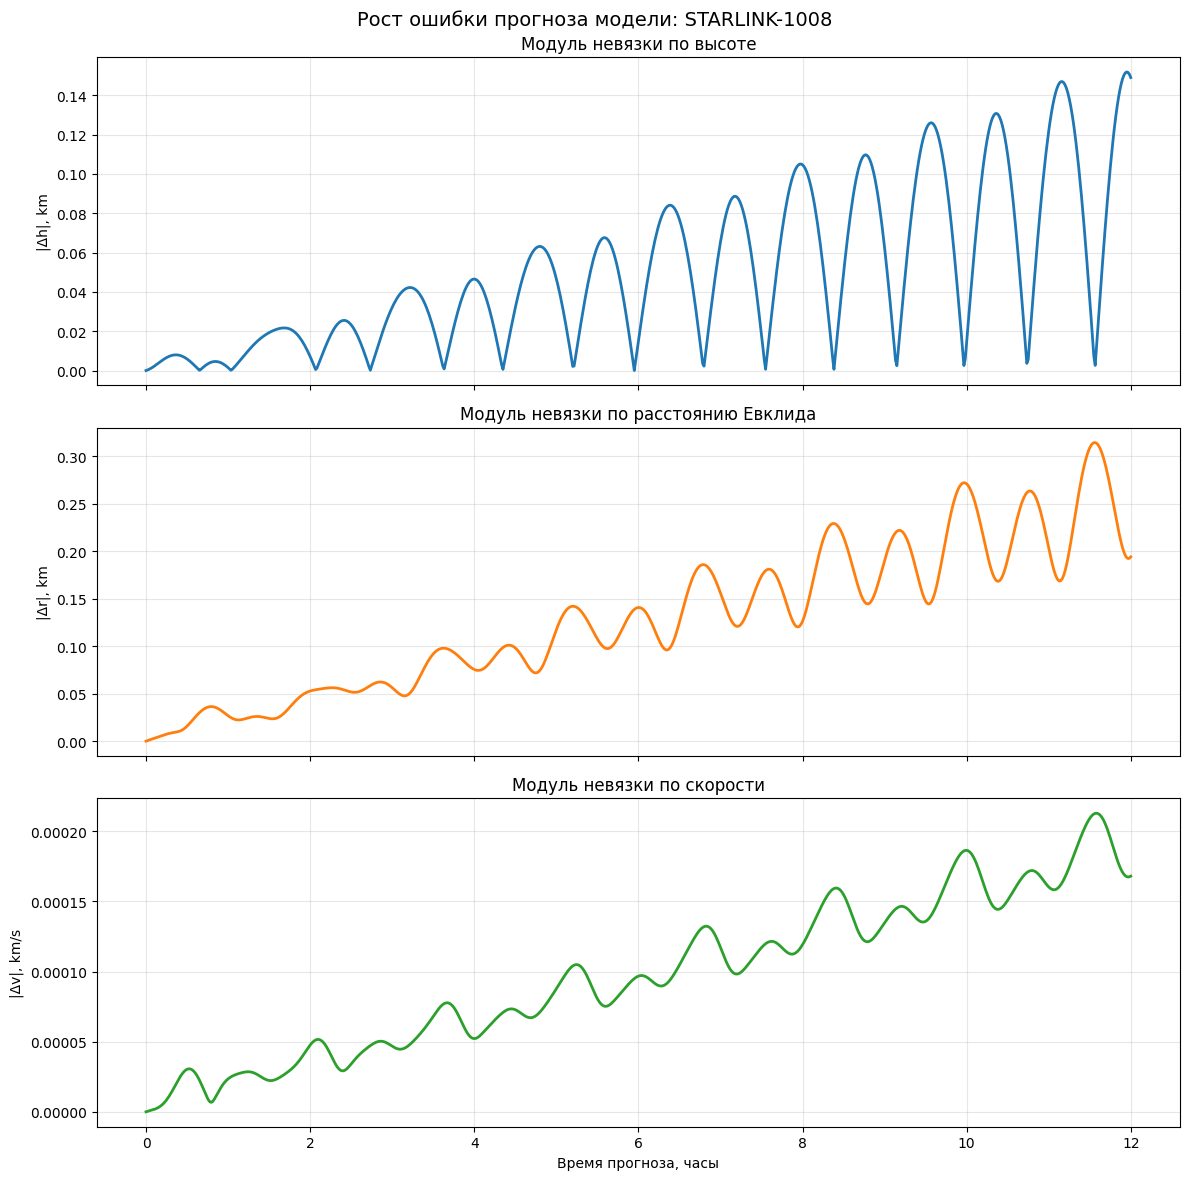

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(t_hours, delta_h_km, color='tab:blue', lw=2)
axes[0].set_ylabel('|Δh|, km')
axes[0].set_title('Модуль невязки по высоте')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_hours, delta_r_km, color='tab:orange', lw=2)
axes[1].set_ylabel('|Δr|, km')
axes[1].set_title('Модуль невязки по расстоянию Евклида')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_hours, delta_v_km_s, color='tab:green', lw=2)
axes[2].set_ylabel('|Δv|, km/s')
axes[2].set_xlabel('Время прогноза, часы')
axes[2].set_title('Модуль невязки по скорости')
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'Рост ошибки прогноза модели: {sat_name}', fontsize=14)
fig.tight_layout()
plt.show()